# 5.5 Visualization Driven Insight Generation

## What is Visualization Driven Insight Generation?

**Visualization Driven Insight Generation** is the process of using visual representations of data to discover patterns, trends, anomalies, and actionable insights that may not be apparent in raw data or tables.

## Why is it Important?

| Aspect | Description |
|--------|-------------|
| **Pattern Recognition** | Humans process visual information 60,000x faster than text |
| **Trend Identification** | Easily spot upward/downward trends over time |
| **Anomaly Detection** | Outliers and unusual patterns stand out visually |
| **Comparison** | Side-by-side visual comparison is intuitive |
| **Communication** | Complex insights become easy to share with stakeholders |
| **Decision Making** | Data-driven decisions become faster and more accurate |

## Types of Insights from Visualization

1. **Descriptive Insights** - What happened? (Summary statistics, distributions)
2. **Diagnostic Insights** - Why did it happen? (Correlations, comparisons)
3. **Predictive Insights** - What might happen? (Trend lines, forecasting)
4. **Prescriptive Insights** - What should we do? (Actionable recommendations)

## Key Visualization Techniques for Insight Generation

| Visualization | Best For | Insight Type |
|---------------|----------|--------------|
| Line Chart | Trends over time | Sales growth, seasonal patterns |
| Bar Chart | Category comparison | Department performance |
| Scatter Plot | Relationships | Correlation between variables |
| Histogram | Distribution | Data spread, skewness |
| Box Plot | Outliers | Detecting anomalies |
| Heatmap | Correlations | Variable relationships |
| Pie Chart | Proportions | Market share |

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Example 1: Trend Analysis - Sales Insight

**Business Question:** How are our monthly sales performing? Is there a trend?

**Insight Type:** Descriptive + Predictive

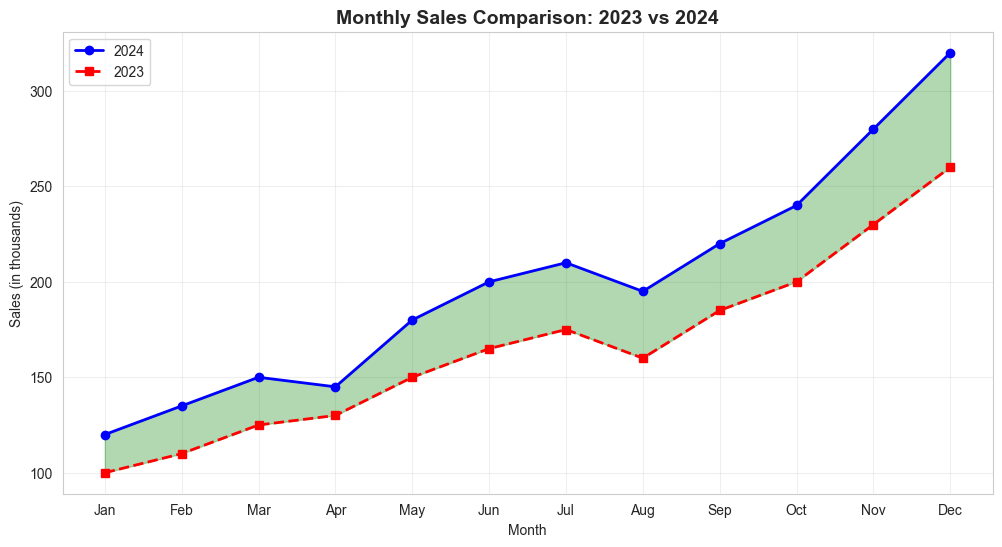

📊 INSIGHTS GENERATED FROM VISUALIZATION:
✅ Overall Trend: Sales are INCREASING throughout the year
✅ Year-over-Year Growth: Average 20.1% increase
✅ Peak Month: Dec with 320K sales
✅ Lowest Month: Jan with 120K sales
✅ Seasonal Pattern: Strong Q4 performance (Oct-Dec)
✅ Actionable: Focus marketing budget on Q4 for maximum ROI


In [3]:
# Example 1: Trend Analysis - Identifying Sales Growth Pattern
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sales_2024 = [120, 135, 150, 145, 180, 200, 210, 195, 220, 240, 280, 320]
sales_2023 = [100, 110, 125, 130, 150, 165, 175, 160, 185, 200, 230, 260]

plt.figure(figsize=(12, 6))
plt.plot(months, sales_2024, marker='o', linewidth=2, label='2024', color='blue')
plt.plot(months, sales_2023, marker='s', linewidth=2, label='2023', color='red', linestyle='--')
plt.fill_between(months, sales_2023, sales_2024, alpha=0.3, color='green')
plt.title('Monthly Sales Comparison: 2023 vs 2024', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales (in thousands)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# INSIGHT GENERATION
growth = [(s24-s23)/s23*100 for s24, s23 in zip(sales_2024, sales_2023)]
print("=" * 60)
print("📊 INSIGHTS GENERATED FROM VISUALIZATION:")
print("=" * 60)
print(f"✅ Overall Trend: Sales are INCREASING throughout the year")
print(f"✅ Year-over-Year Growth: Average {np.mean(growth):.1f}% increase")
print(f"✅ Peak Month: {months[np.argmax(sales_2024)]} with {max(sales_2024)}K sales")
print(f"✅ Lowest Month: {months[np.argmin(sales_2024)]} with {min(sales_2024)}K sales")
print(f"✅ Seasonal Pattern: Strong Q4 performance (Oct-Dec)")
print(f"✅ Actionable: Focus marketing budget on Q4 for maximum ROI")

## Example 2: Distribution Analysis - Detecting Anomalies

**Business Question:** Are there any outliers in student marks? Who needs attention?

**Insight Type:** Diagnostic (Anomaly Detection)

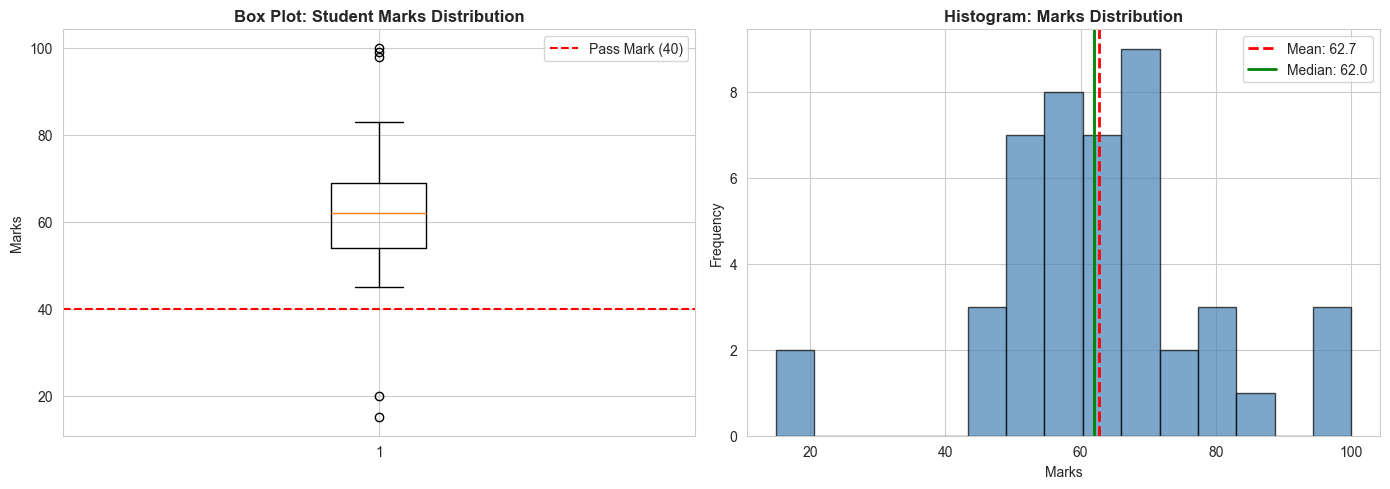

📊 INSIGHTS GENERATED FROM VISUALIZATION:
✅ Distribution: Approximately Normal with outliers
✅ Central Tendency: Mean=62.7, Median=62.0
✅ Spread: Std Dev=16.1
✅ Outliers Detected: 5 students - Marks: [np.int64(15), np.int64(20), np.int64(98), np.int64(99), np.int64(100)]
✅ Low Performers: 2 students below passing marks
✅ Top Performers: 3 students scored 90+
✅ Actionable: Provide remedial classes for students scoring below 40


In [4]:
# Example 2: Box Plot for Outlier Detection
np.random.seed(42)
# Normal students
normal_marks = np.random.normal(65, 10, 40).astype(int)
# Add some outliers (very low and very high performers)
outlier_marks = np.array([15, 20, 98, 99, 100])
all_marks = np.concatenate([normal_marks, outlier_marks])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box Plot
axes[0].boxplot(all_marks, vert=True)
axes[0].set_title('Box Plot: Student Marks Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Marks')
axes[0].axhline(y=40, color='red', linestyle='--', label='Pass Mark (40)')
axes[0].legend()

# Histogram with KDE
axes[1].hist(all_marks, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=np.mean(all_marks), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_marks):.1f}')
axes[1].axvline(x=np.median(all_marks), color='green', linestyle='-', linewidth=2, label=f'Median: {np.median(all_marks):.1f}')
axes[1].set_title('Histogram: Marks Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Marks')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# INSIGHT GENERATION
Q1 = np.percentile(all_marks, 25)
Q3 = np.percentile(all_marks, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = all_marks[(all_marks < lower_bound) | (all_marks > upper_bound)]

print("=" * 60)
print("📊 INSIGHTS GENERATED FROM VISUALIZATION:")
print("=" * 60)
print(f"✅ Distribution: Approximately Normal with outliers")
print(f"✅ Central Tendency: Mean={np.mean(all_marks):.1f}, Median={np.median(all_marks):.1f}")
print(f"✅ Spread: Std Dev={np.std(all_marks):.1f}")
print(f"✅ Outliers Detected: {len(outliers)} students - Marks: {sorted(outliers)}")
print(f"✅ Low Performers: {len(all_marks[all_marks < 40])} students below passing marks")
print(f"✅ Top Performers: {len(all_marks[all_marks >= 90])} students scored 90+")
print(f"✅ Actionable: Provide remedial classes for students scoring below 40")

## Example 3: Correlation Analysis - Understanding Relationships

**Business Question:** What factors influence customer satisfaction?

**Insight Type:** Diagnostic (Cause-Effect Relationship)

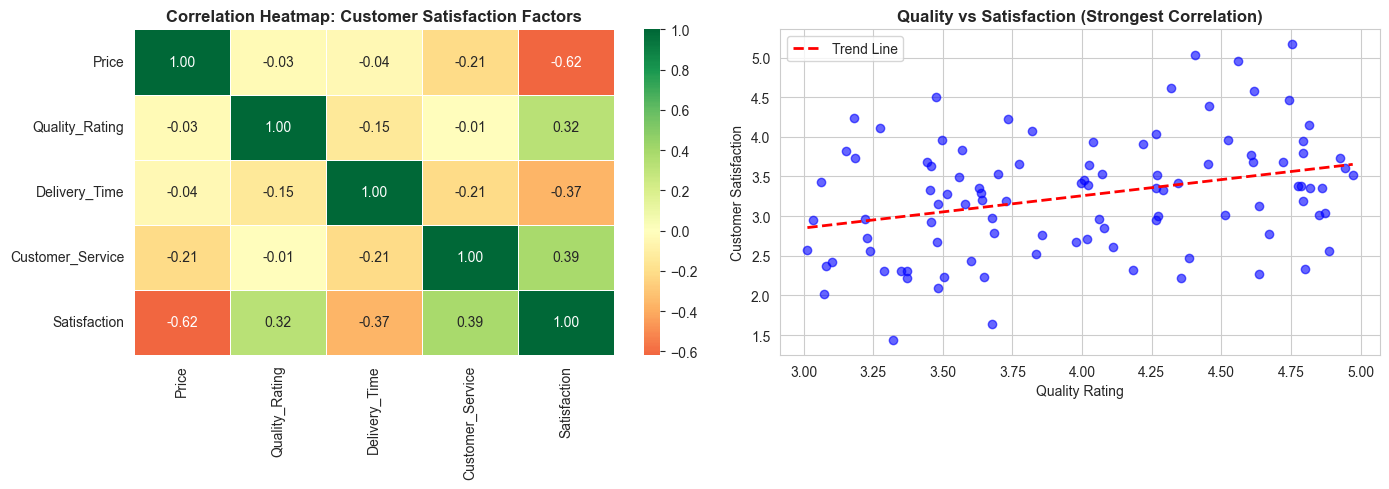

📊 INSIGHTS GENERATED FROM VISUALIZATION:
Correlation with Customer Satisfaction:
  • Customer_Service: 0.387 (Moderate Positive ↑)
  • Quality_Rating: 0.321 (Moderate Positive ↑)
  • Delivery_Time: -0.367 (Moderate Negative ↓)
  • Price: -0.618 (Strong Negative ↓)

✅ Key Driver: Customer_Service has the strongest impact
✅ Secondary Driver: Quality_Rating
✅ Negative Impact: Price (Higher = Lower Satisfaction)
✅ Actionable: Invest in improving Customer_Service for maximum impact


In [5]:
# Example 3: Correlation Heatmap for Relationship Discovery
np.random.seed(42)
n = 100

# Create correlated data (simulating business metrics)
data = {
    'Price': np.random.uniform(10, 100, n),
    'Quality_Rating': np.random.uniform(3, 5, n),
    'Delivery_Time': np.random.uniform(1, 10, n),
    'Customer_Service': np.random.uniform(3, 5, n),
}
# Satisfaction is influenced by these factors
data['Satisfaction'] = (
    0.3 * (100 - data['Price']) / 100 +  # Lower price = higher satisfaction
    0.35 * data['Quality_Rating'] / 5 +   # Higher quality = higher satisfaction
    0.15 * (10 - data['Delivery_Time']) / 10 +  # Faster delivery = higher satisfaction
    0.2 * data['Customer_Service'] / 5 +  # Better service = higher satisfaction
    np.random.normal(0, 0.1, n)
) * 5

df = pd.DataFrame(data)

# Create correlation matrix
corr_matrix = df.corr()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, 
            fmt='.2f', ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlation Heatmap: Customer Satisfaction Factors', fontsize=12, fontweight='bold')

# Scatter plot for strongest correlation
axes[1].scatter(df['Quality_Rating'], df['Satisfaction'], alpha=0.6, c='blue')
z = np.polyfit(df['Quality_Rating'], df['Satisfaction'], 1)
p = np.poly1d(z)
axes[1].plot(df['Quality_Rating'].sort_values(), p(df['Quality_Rating'].sort_values()), 
             "r--", linewidth=2, label='Trend Line')
axes[1].set_xlabel('Quality Rating')
axes[1].set_ylabel('Customer Satisfaction')
axes[1].set_title('Quality vs Satisfaction (Strongest Correlation)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# INSIGHT GENERATION
satisfaction_corr = corr_matrix['Satisfaction'].drop('Satisfaction').sort_values(ascending=False)
print("=" * 60)
print("📊 INSIGHTS GENERATED FROM VISUALIZATION:")
print("=" * 60)
print("Correlation with Customer Satisfaction:")
for factor, corr in satisfaction_corr.items():
    direction = "Positive ↑" if corr > 0 else "Negative ↓"
    strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
    print(f"  • {factor}: {corr:.3f} ({strength} {direction})")
print()
print(f"✅ Key Driver: {satisfaction_corr.index[0]} has the strongest impact")
print(f"✅ Secondary Driver: {satisfaction_corr.index[1]}")
print(f"✅ Negative Impact: {satisfaction_corr.index[-1]} (Higher = Lower Satisfaction)")
print(f"✅ Actionable: Invest in improving {satisfaction_corr.index[0]} for maximum impact")

## Example 4: Comparative Analysis - Performance Benchmarking

**Business Question:** Which department is performing best? Where should we focus?

**Insight Type:** Descriptive + Prescriptive

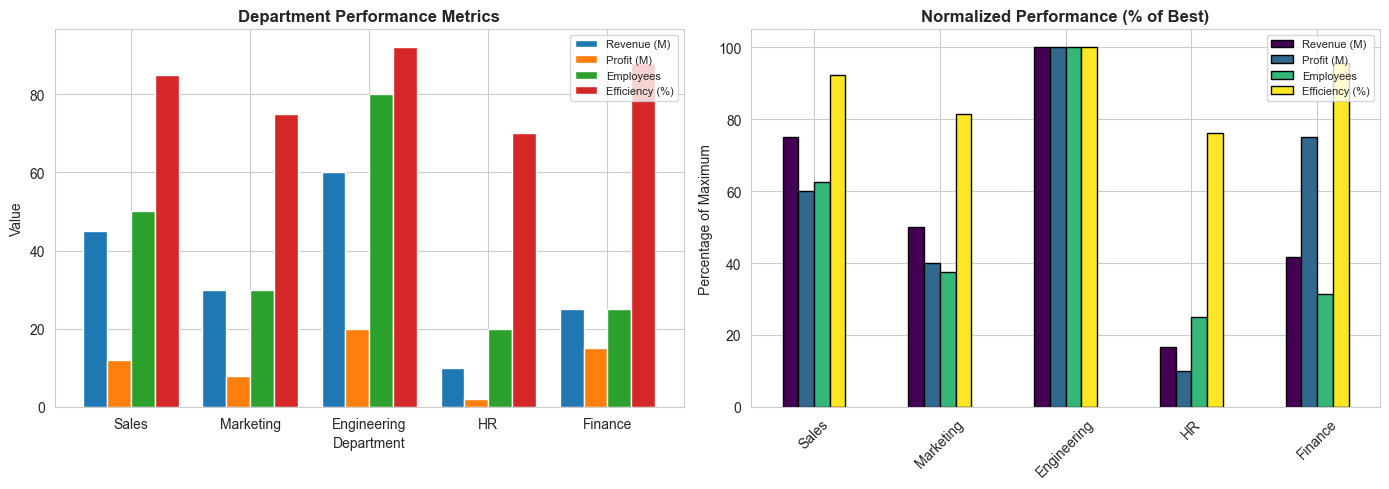

📊 INSIGHTS GENERATED FROM VISUALIZATION:
✅ Highest Revenue: Engineering ($60M)
✅ Highest Profit: Engineering ($20M)
✅ Most Efficient: Engineering (92%)
✅ Least Efficient: HR (70%) - Needs improvement
✅ Best Profit Margin: Finance (60.0%)
✅ Actionable: Focus on improving HR's efficiency
✅ Actionable: Study Engineering's practices for best practices sharing


In [6]:
# Example 4: Grouped Bar Chart for Department Comparison
departments = ['Sales', 'Marketing', 'Engineering', 'HR', 'Finance']
metrics = {
    'Revenue (M)': [45, 30, 60, 10, 25],
    'Profit (M)': [12, 8, 20, 2, 15],
    'Employees': [50, 30, 80, 20, 25],
    'Efficiency (%)': [85, 75, 92, 70, 88]
}

df = pd.DataFrame(metrics, index=departments)

# Normalize for comparison (percentage of max)
df_normalized = df.apply(lambda x: (x / x.max()) * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped Bar Chart
x = np.arange(len(departments))
width = 0.2
multiplier = 0

for attribute, measurement in metrics.items():
    offset = width * multiplier
    axes[0].bar(x + offset, measurement, width, label=attribute)
    multiplier += 1

axes[0].set_xlabel('Department')
axes[0].set_ylabel('Value')
axes[0].set_title('Department Performance Metrics', fontsize=12, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(departments)
axes[0].legend(loc='upper right', fontsize=8)

# Radar Chart style comparison using bar
df_normalized.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='black')
axes[1].set_title('Normalized Performance (% of Best)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage of Maximum')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xticklabels(departments, rotation=45)

plt.tight_layout()
plt.show()

# INSIGHT GENERATION
print("=" * 60)
print("📊 INSIGHTS GENERATED FROM VISUALIZATION:")
print("=" * 60)
best_revenue = departments[np.argmax(metrics['Revenue (M)'])]
best_profit = departments[np.argmax(metrics['Profit (M)'])]
best_efficiency = departments[np.argmax(metrics['Efficiency (%)'])]
worst_efficiency = departments[np.argmin(metrics['Efficiency (%)'])]

# Calculate profit margin
profit_margin = [p/r*100 for p, r in zip(metrics['Profit (M)'], metrics['Revenue (M)'])]
best_margin_idx = np.argmax(profit_margin)

print(f"✅ Highest Revenue: {best_revenue} (${max(metrics['Revenue (M)'])}M)")
print(f"✅ Highest Profit: {best_profit} (${max(metrics['Profit (M)'])}M)")
print(f"✅ Most Efficient: {best_efficiency} ({max(metrics['Efficiency (%)'])}%)")
print(f"✅ Least Efficient: {worst_efficiency} ({min(metrics['Efficiency (%)'])}%) - Needs improvement")
print(f"✅ Best Profit Margin: {departments[best_margin_idx]} ({profit_margin[best_margin_idx]:.1f}%)")
print(f"✅ Actionable: Focus on improving {worst_efficiency}'s efficiency")
print(f"✅ Actionable: Study {best_efficiency}'s practices for best practices sharing")

## Example 5: Composition Analysis - Market Share Insight

**Business Question:** How is the market divided? Who are the major players?

**Insight Type:** Descriptive (Proportional Analysis)

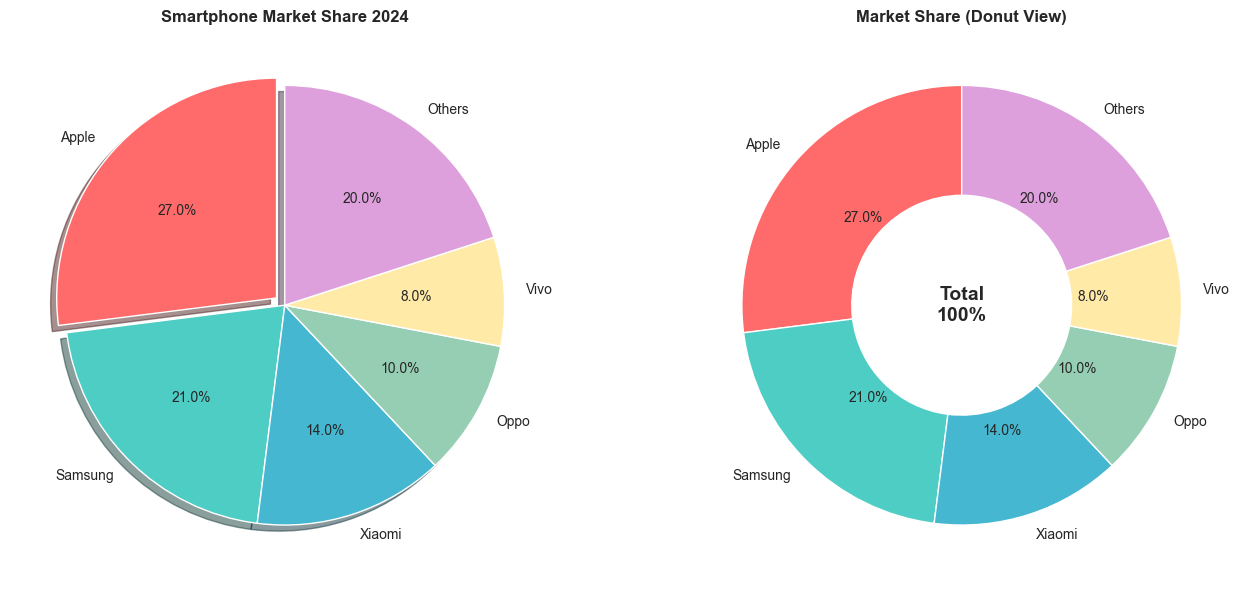

📊 INSIGHTS GENERATED FROM VISUALIZATION:
✅ Market Leader: Apple with 27% share
✅ Top 2 Control: 48% of the market
✅ Top 3 Control: 62% of the market
✅ Fragmented Market: 'Others' hold 20% (opportunity for new entrants)
✅ Competition: Close race between Apple and Samsung (only 6% gap)
✅ Actionable: For new entrant, target the 'Others' segment first
✅ Actionable: Samsung should focus on gaining 7% to become market leader


In [7]:
# Example 5: Pie Chart for Market Share Analysis
companies = ['Apple', 'Samsung', 'Xiaomi', 'Oppo', 'Vivo', 'Others']
market_share = [27, 21, 14, 10, 8, 20]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Regular Pie Chart
explode = (0.05, 0, 0, 0, 0, 0)  # Highlight leader
axes[0].pie(market_share, labels=companies, autopct='%1.1f%%', colors=colors,
            explode=explode, shadow=True, startangle=90)
axes[0].set_title('Smartphone Market Share 2024', fontsize=12, fontweight='bold')

# Donut Chart with center text
wedges, texts, autotexts = axes[1].pie(market_share, labels=companies, autopct='%1.1f%%',
                                        colors=colors, startangle=90, 
                                        wedgeprops=dict(width=0.5))
centre_circle = plt.Circle((0, 0), 0.35, fc='white')
axes[1].add_patch(centre_circle)
axes[1].text(0, 0, 'Total\n100%', ha='center', va='center', fontsize=14, fontweight='bold')
axes[1].set_title('Market Share (Donut View)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# INSIGHT GENERATION
total = sum(market_share)
sorted_idx = np.argsort(market_share)[::-1]
cumulative = np.cumsum([market_share[i] for i in sorted_idx])

print("=" * 60)
print("📊 INSIGHTS GENERATED FROM VISUALIZATION:")
print("=" * 60)
print(f"✅ Market Leader: {companies[0]} with {market_share[0]}% share")
print(f"✅ Top 2 Control: {market_share[0] + market_share[1]}% of the market")
print(f"✅ Top 3 Control: {market_share[0] + market_share[1] + market_share[2]}% of the market")
print(f"✅ Fragmented Market: 'Others' hold {market_share[-1]}% (opportunity for new entrants)")
print(f"✅ Competition: Close race between {companies[0]} and {companies[1]} (only {market_share[0]-market_share[1]}% gap)")
print(f"✅ Actionable: For new entrant, target the 'Others' segment first")
print(f"✅ Actionable: {companies[1]} should focus on gaining 7% to become market leader")

## Example 6: Time Series Pattern Recognition

**Business Question:** Are there seasonal patterns in our data? When are peak/low periods?

**Insight Type:** Descriptive + Predictive (Seasonality)

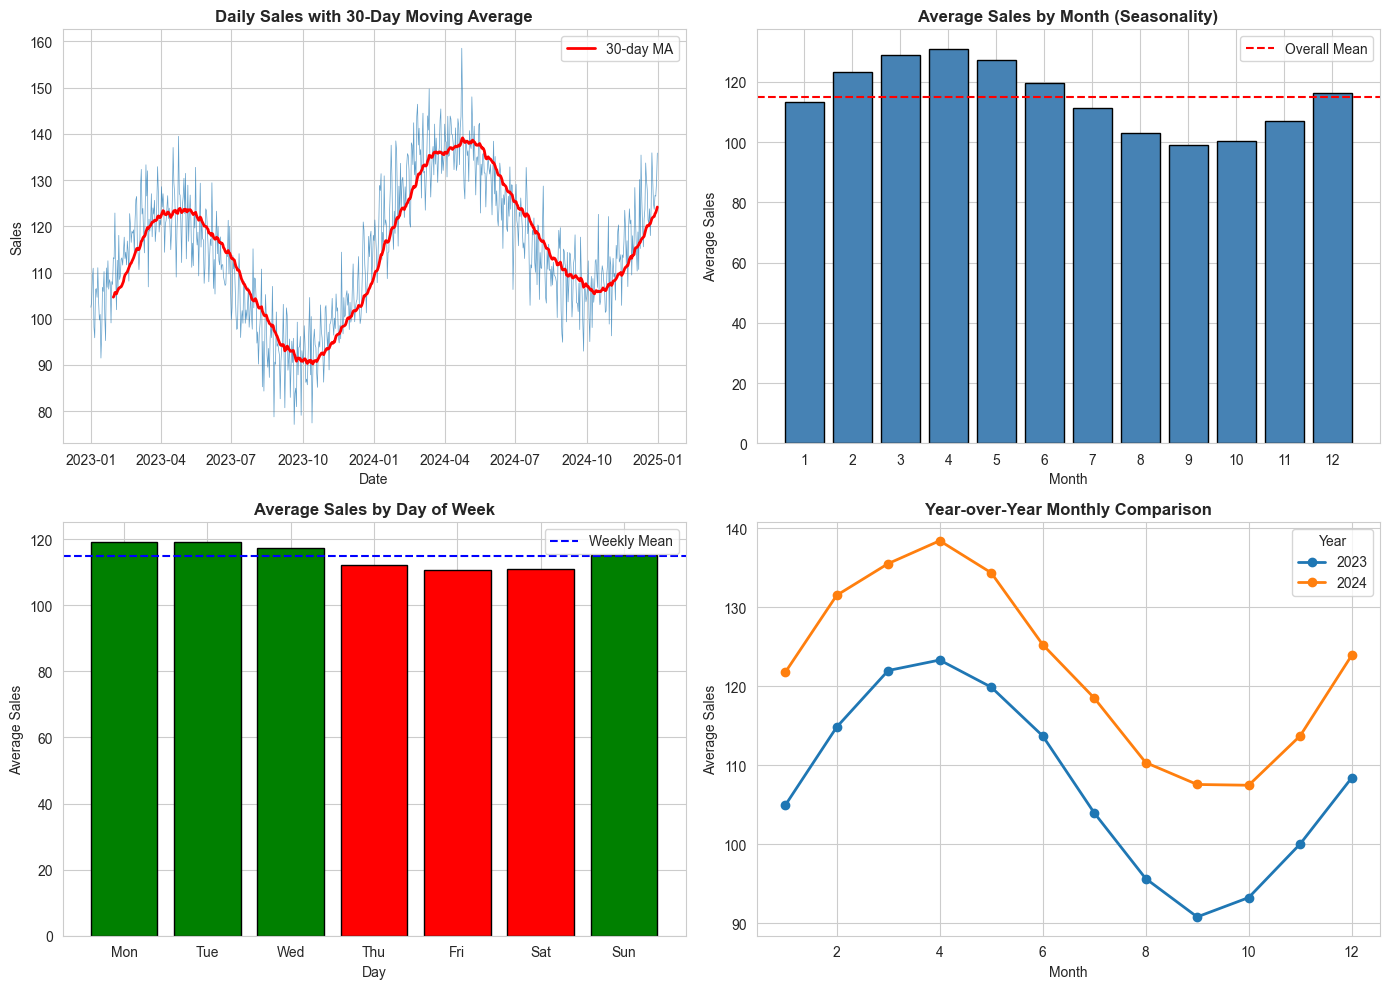

📊 INSIGHTS GENERATED FROM VISUALIZATION:
✅ Overall Trend: Sales are GROWING over time
✅ Peak Month: Apr (Avg: 130.9)
✅ Low Month: Sep (Avg: 99.2)
✅ Peak Day: Monday (Best day for sales)
✅ Low Day: Friday (Slowest day)
✅ Seasonal Pattern: Clear yearly cycle visible
✅ Actionable: Increase inventory for Apr
✅ Actionable: Run promotions on Friday to boost sales


In [8]:
# Example 6: Seasonal Pattern Detection
np.random.seed(42)

# Create 2 years of daily data with seasonal pattern
dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
# Base trend + seasonal component + noise
base = 100
trend = np.linspace(0, 30, len(dates))  # Growing trend
seasonal = 20 * np.sin(2 * np.pi * np.arange(len(dates)) / 365)  # Yearly seasonality
weekly = 5 * np.sin(2 * np.pi * np.arange(len(dates)) / 7)  # Weekly pattern
noise = np.random.normal(0, 5, len(dates))
sales = base + trend + seasonal + weekly + noise

df = pd.DataFrame({'Date': dates, 'Sales': sales})
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time Series Plot
axes[0, 0].plot(df['Date'], df['Sales'], alpha=0.7, linewidth=0.5)
axes[0, 0].plot(df['Date'], df['Sales'].rolling(30).mean(), color='red', linewidth=2, label='30-day MA')
axes[0, 0].set_title('Daily Sales with 30-Day Moving Average', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Sales')
axes[0, 0].legend()

# Monthly Average
monthly_avg = df.groupby('Month')['Sales'].mean()
axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='black')
axes[0, 1].axhline(y=monthly_avg.mean(), color='red', linestyle='--', label='Overall Mean')
axes[0, 1].set_title('Average Sales by Month (Seasonality)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Sales')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend()

# Day of Week Pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('DayOfWeek')['Sales'].mean().reindex(dow_order)
colors = ['green' if x > dow_avg.mean() else 'red' for x in dow_avg.values]
axes[1, 0].bar(range(7), dow_avg.values, color=colors, edgecolor='black')
axes[1, 0].axhline(y=dow_avg.mean(), color='blue', linestyle='--', label='Weekly Mean')
axes[1, 0].set_title('Average Sales by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Average Sales')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 0].legend()

# Year over Year Comparison
yearly_monthly = df.groupby(['Year', 'Month'])['Sales'].mean().unstack(level=0)
yearly_monthly.plot(kind='line', ax=axes[1, 1], marker='o', linewidth=2)
axes[1, 1].set_title('Year-over-Year Monthly Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Sales')
axes[1, 1].legend(title='Year')

plt.tight_layout()
plt.show()

# INSIGHT GENERATION
peak_month = monthly_avg.idxmax()
low_month = monthly_avg.idxmin()
peak_day = dow_avg.idxmax()
low_day = dow_avg.idxmin()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("=" * 60)
print("📊 INSIGHTS GENERATED FROM VISUALIZATION:")
print("=" * 60)
print(f"✅ Overall Trend: Sales are GROWING over time")
print(f"✅ Peak Month: {month_names[peak_month-1]} (Avg: {monthly_avg[peak_month]:.1f})")
print(f"✅ Low Month: {month_names[low_month-1]} (Avg: {monthly_avg[low_month]:.1f})")
print(f"✅ Peak Day: {peak_day} (Best day for sales)")
print(f"✅ Low Day: {low_day} (Slowest day)")
print(f"✅ Seasonal Pattern: Clear yearly cycle visible")
print(f"✅ Actionable: Increase inventory for {month_names[peak_month-1]}")
print(f"✅ Actionable: Run promotions on {low_day} to boost sales")

## Example 7: Interactive Insight Generation with Plotly

**Using Plotly for exploratory data analysis with interactive hover insights**

In [9]:
# Example 7: Interactive Dashboard for Multi-dimensional Insight
np.random.seed(42)

# Create sample business data
n = 50
data = {
    'Product': [f'Product_{i+1}' for i in range(n)],
    'Category': np.random.choice(['Electronics', 'Clothing', 'Food', 'Home'], n),
    'Revenue': np.random.uniform(1000, 50000, n),
    'Units_Sold': np.random.randint(10, 500, n),
    'Profit_Margin': np.random.uniform(5, 40, n),
    'Customer_Rating': np.random.uniform(3, 5, n)
}
df = pd.DataFrame(data)
df['Profit'] = df['Revenue'] * df['Profit_Margin'] / 100

# Interactive Scatter Plot with multiple dimensions
fig = px.scatter(df, 
                 x='Revenue', 
                 y='Profit',
                 size='Units_Sold',
                 color='Category',
                 hover_name='Product',
                 hover_data=['Customer_Rating', 'Profit_Margin'],
                 title='Product Performance Analysis (Hover for details)',
                 labels={'Revenue': 'Revenue ($)', 'Profit': 'Profit ($)'})

fig.update_layout(
    xaxis_title='Revenue ($)',
    yaxis_title='Profit ($)',
    legend_title='Category'
)
fig.show()

# Generate Insights
print("=" * 60)
print("📊 INSIGHTS FROM INTERACTIVE EXPLORATION:")
print("=" * 60)
for cat in df['Category'].unique():
    cat_df = df[df['Category'] == cat]
    print(f"\n📁 {cat}:")
    print(f"   • Total Revenue: ${cat_df['Revenue'].sum():,.0f}")
    print(f"   • Avg Profit Margin: {cat_df['Profit_Margin'].mean():.1f}%")
    print(f"   • Top Product: {cat_df.loc[cat_df['Profit'].idxmax(), 'Product']}")

# Best and worst performers
best_product = df.loc[df['Profit'].idxmax()]
worst_product = df.loc[df['Profit'].idxmin()]
print(f"\n✅ Best Performer: {best_product['Product']} (Profit: ${best_product['Profit']:,.0f})")
print(f"⚠️ Needs Attention: {worst_product['Product']} (Profit: ${worst_product['Profit']:,.0f})")

📊 INSIGHTS FROM INTERACTIVE EXPLORATION:

📁 Food:
   • Total Revenue: $282,338
   • Avg Profit Margin: 19.9%
   • Top Product: Product_11

📁 Home:
   • Total Revenue: $379,104
   • Avg Profit Margin: 22.8%
   • Top Product: Product_46

📁 Electronics:
   • Total Revenue: $194,637
   • Avg Profit Margin: 21.8%
   • Top Product: Product_31

📁 Clothing:
   • Total Revenue: $379,848
   • Avg Profit Margin: 16.6%
   • Top Product: Product_10

✅ Best Performer: Product_46 (Profit: $15,218)
⚠️ Needs Attention: Product_48 (Profit: $78)


## Summary: Visualization Driven Insight Generation Process

### The 5-Step Framework for Insight Generation

```
┌─────────────────────────────────────────────────────────────┐
│  1. QUESTION → 2. VISUALIZE → 3. OBSERVE → 4. INSIGHT → 5. ACTION │
└─────────────────────────────────────────────────────────────┘
```

| Step | Description | Example |
|------|-------------|---------|
| **1. Question** | Define what you want to know | "Why are sales declining?" |
| **2. Visualize** | Choose appropriate chart type | Line chart for trends |
| **3. Observe** | Look for patterns, outliers, trends | Notice Q3 dip |
| **4. Insight** | Draw conclusions from observations | "Summer months have low sales" |
| **5. Action** | Make data-driven decisions | "Launch summer promotions" |

### Visualization Selection Guide

| Question Type | Best Visualization | Insight Type |
|--------------|-------------------|--------------|
| How has X changed over time? | Line Chart | Trend |
| How do categories compare? | Bar Chart | Comparison |
| What is the distribution? | Histogram, Box Plot | Distribution |
| What is the relationship? | Scatter Plot, Heatmap | Correlation |
| What are the proportions? | Pie Chart, Stacked Bar | Composition |
| Are there outliers? | Box Plot, Scatter Plot | Anomaly |
| What is the pattern? | Time Series, Heatmap | Seasonality |

### Key Takeaways

1. **Choose the Right Chart** - Match visualization to your question
2. **Look for Patterns** - Trends, clusters, gaps, outliers
3. **Use Interactivity** - Plotly enables deeper exploration
4. **Generate Actionable Insights** - Every insight should lead to a decision
5. **Tell a Story** - Visualizations should communicate clearly

### Common Insights from Visualizations

- 📈 **Trends**: Upward/downward movement over time
- 📊 **Comparisons**: Which category performs best/worst
- 🔗 **Correlations**: Relationships between variables
- 🎯 **Outliers**: Unusual data points requiring attention
- 📅 **Seasonality**: Recurring patterns at regular intervals
- 📉 **Anomalies**: Unexpected deviations from normal